# MiniProyecto 2: Segmentación de higado en volumenes MRI

## Entrega 2:
En la anterior entrega hemos desarrollado un algoritmo completo de segmentación para el hígado en MRIs. Los resultados no son perfectos y tendremos numerosos falsos positivos, falsos negativos, huecos, protuberancias y bahias dentro de nuetras mascaras de segmentación que disminuirán nuestras metricas de evaluación. Para poder refinar nuestros resultados tenemos 2 posibilidades, mejorar las imagenes originales para facilitar el trabajo del algoritmo de predicción en las zonas de peor rendimiento o mejorar la mascara de predicción con morfología matematica para pulir las imperfecciones y subir las métricas de evaluación.

### Parte 1: Operación morfológica como pre-procesamiento
Hasta ahora, hemos realizado un proceso de pre-procesamiento basado unicamente en la corrección de intensidades y la ecualización o especificación de histogramas. Estos procesos se basan casi exclusivamente en las intensidades de los pixeles, obviando la posible relación entre los pixeles y sus vecindades. En esta ocasión, usaremos las herramientas de la morfología matematica pero aplicada a **escala de grises** como metodo de pre-procesamiento.

#### Parte 1.1: Visualización de errores
Antes de realizar cualquier pre-procesamiento es importante entender nuestras imagenes y las limitaciones de nuestro modelo para poder diseñar una metodología eficaz que mejore nuestros resultados y no nos resulte perjudicial. Tampoco nos funcionará realizar una metodología de pre-procesamiento a ciegas, siempre es importante comprender nuestro modelo y nuestras imagenes para no solo diseñar un metodo que nos funcione en una base de datos en especifico, sino que sea los mas generalizable posible. 


Cargue el volumen segmentation-1.nii.gz y el volumen volume-1.nii.gz de la base de datos de entrenamiento, luego utilice la función de umbralización creada en la entrega anterior utilizando un valor minimo de 30 y maximo de 220 para generar una predicción. Por ultimo, visualize las estructuras de el **volumen original** que usted esta segmentando con su algoritmo. Haga una función que cree 2 volumenes adicionales, uno que contenga unicamente los pixeles falsos positivos y otro que contenga unicamente los pixeles falsos negativos. Para el subplot encuentre en cada volumen los slices (axial, transversal y sagital) con mayor cantidad de errores.

> **Nota:** Recuerde que los FP serán aquellos pixeles que se encuentran en su prediccion pero no en su groundtruth. Los FN serán los pixeles que se encuentran en su groundtruth pero no en su predicción.

In [2]:
import os
import numpy as np
from glob import glob
import nibabel as nib
from matplotlib import pyplot as plt

from tqdm import tqdm

from skimage.measure import label
from skimage.morphology import ball, erosion, dilation, closing, opening, white_tophat, black_tophat

In [3]:
def vol_max_component(volume, max=1, min=0):
    """Esta función realiza la segmentación mediante elemento conexo más grande en 3D

    Args:
        volume (np.ndarray): Volumen a segmentar
        max (float | None): Limite inferior para realizar la segmentación
        min (float | None): Limite superior para realiza la segmentación

    Return:
        (np.ndarray): Volumen segmentado
    """
    segment_vol = "" # Volumen segmentado
     # 1. Crear la máscara binaria basada en los umbrales (Thresholding)
    mask = (volume > min) & (volume < max)
    
    # 2. Etiquetar todos los objetos conexos en el volumen 3D
    # label() identifica grupos de voxeles que se tocan entre sí
    labeled_vol = label(mask)
    
    # 3. Si no se encontró ningún objeto, retornamos un volumen vacío
    if labeled_vol.max() == 0:
        return np.zeros_like(volume, dtype=np.uint8)
    
    # 4. Contar cuántos voxeles tiene cada etiqueta
    # np.bincount cuenta la frecuencia de cada número en el arreglo
    counts = np.bincount(labeled_vol.ravel())
    
    # 5. Ignoramos la etiqueta 0 (que es el fondo) y buscamos el índice del máximo
    # Sumamos 1 porque el slice [1:] desplaza los índices
    max_label = np.argmax(counts[1:]) + 1
    
    # 6. Creamos el volumen final solo con el objeto más grande
    segment_vol = (labeled_vol == max_label).astype(np.uint8)
    
    return segment_vol

In [5]:
volume1='' #volumen 1 de entrenamiento
segmen1='' #segmentacion del volumen 1 de entrenamiento, groundtruth
segment_pred='' #volumen de prediccion de su algoritmo
FN_volumes='' #volumen unicamente con pixeles Falsos Negativos
FP_volumes='' #volumen unicamente con pixeles Falsos Positivos


volume1 = nib.load(os.path.join('DB', 'train', 'volume_1.nii.gz')).get_fdata()
segmen1 = nib.load(os.path.join('DB', 'train', 'segmentation_1.nii.gz')).get_fdata()

## Convertir la segmentación a binario: 1 donde hay hígado, 0 donde no
segmen1 = (segmen1 > 0).astype(int)

# Generar la predicción usando umbralización
segment_pred = vol_max_component(volume1, max=220, min=30)


def errores(segment_pred,segmen1):
    'segment_pred (ndarray): volumen de predicción'
    'segmen1 (ndarray): volumen de groundtruth'
    
    FP_volumes = (segment_pred == 1) & (segmen1 == 0) # Falsos Positivos: Predice hígado donde no hay
    FN_volumes = (segment_pred == 0) & (segmen1 == 1) # Falsos Negativos: No predice hígado donde sí hay
    
    #conversion a uint8
    FP_volumes = FP_volumes.astype(np.uint8)
    FN_volumes = FN_volumes.astype(np.uint8)
    
    return FP_volumes,FN_volumes
    


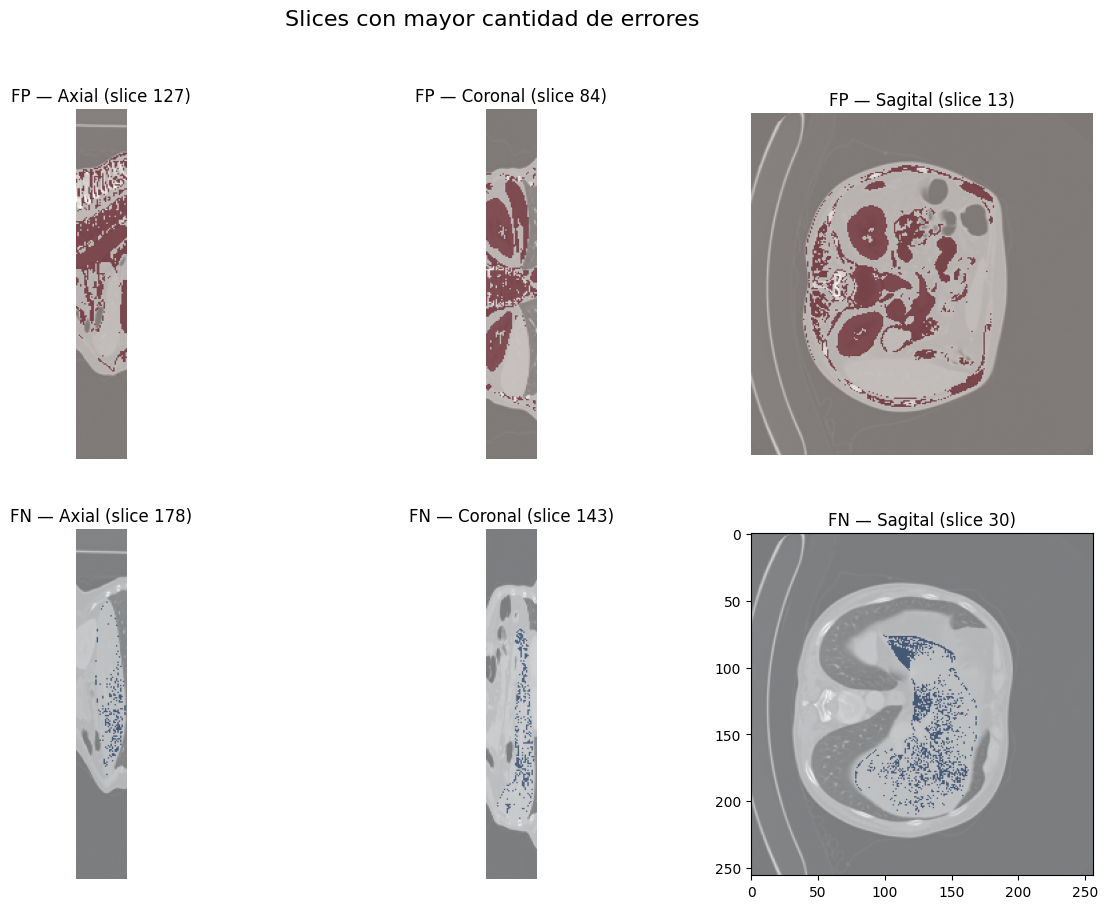

In [ ]:
def visualizar_errores(volume1, FP_volumes, FN_volumes):
    """Encuentra los slices con más errores en cada eje y los visualiza.

    Args:
        volume1 (ndarray): Volumen MRI original
        FP_volumes (ndarray): Volumen con únicamente píxeles Falsos Positivos
        FN_volumes (ndarray): Volumen con únicamente píxeles Falsos Negativos
    """

    
    # Sumamos manualmente en los dos ejes que NO son el de interés
    # Eje 0 → axial: sumamos sobre ejes 1 y 2 usando dos .sum() encadenados
    fp_axial   = np.argmax(FP_volumes.sum(axis=1).sum(axis=1))
    fn_axial   = np.argmax(FN_volumes.sum(axis=1).sum(axis=1))

    # Eje 1 → coronal: sumamos sobre ejes 0 y 2
    fp_coronal = np.argmax(FP_volumes.sum(axis=0).sum(axis=1))
    fn_coronal = np.argmax(FN_volumes.sum(axis=0).sum(axis=1))

    # Eje 2 → sagital: sumamos sobre ejes 0 y 1
    fp_sagital = np.argmax(FP_volumes.sum(axis=0).sum(axis=0))
    fn_sagital = np.argmax(FN_volumes.sum(axis=0).sum(axis=0))

    # ── Crear el subplot ───────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Slices con mayor cantidad de errores', fontsize=16)

    # ── Fila 0: Falsos Positivos (rojo) ───────────────────────────────────────
    axes[0, 0].imshow(volume1[fp_axial, :, :], cmap='gray')
    axes[0, 0].imshow(FP_volumes[fp_axial, :, :], cmap='Reds', alpha=0.5)
    axes[0, 0].set_title(f'FP — Axial (slice {fp_axial})')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(volume1[:, fp_coronal, :], cmap='gray')
    axes[0, 1].imshow(FP_volumes[:, fp_coronal, :], cmap='Reds', alpha=0.5)
    axes[0, 1].set_title(f'FP — Coronal (slice {fp_coronal})')
    axes[0, 1].axis('off')

    axes[0, 2].imshow(volume1[:, :, fp_sagital], cmap='gray')
    axes[0, 2].imshow(FP_volumes[:, :, fp_sagital], cmap='Reds', alpha=0.5)
    axes[0, 2].set_title(f'FP — Sagital (slice {fp_sagital})')
    axes[0, 2].axis('off')

    # ── Fila 1: Falsos Negativos (azul) ───────────────────────────────────────
    axes[1, 0].imshow(volume1[fn_axial, :, :], cmap='gray')
    axes[1, 0].imshow(FN_volumes[fn_axial, :, :], cmap='Blues', alpha=0.5)
    axes[1, 0].set_title(f'FN — Axial (slice {fn_axial})')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(volume1[:, fn_coronal, :], cmap='gray')
    axes[1, 1].imshow(FN_volumes[:, fn_coronal, :], cmap='Blues', alpha=0.5)
    axes[1, 1].set_title(f'FN — Coronal (slice {fn_coronal})')
    axes[1, 1].axis('off')

    axes[1, 2].imshow(volume1[:, :, fn_sagital], cmap='gray')
    axes[1, 2].imshow(FN_volumes[:, :, fn_sagital], cmap='Blues', alpha=0.5)
    axes[1, 2].set_title(f'FN — Sagital (slice {fn_sagital})')

visualizar_errores(volume1, FP_volumes, FN_volumes)

In [13]:
assert np.isclose(np.sum(volume1),-1550711485.0,0.01), 'No se abrió el volumen 1'
assert len(np.unique(segmen1))==2, f'Las etiquetas del volumen de anotacion deben ser 2 y son {len(np.unique(segmen1))}, puede que haya guardado el volumen 1 en esta variable o no haya contado la etiqueta 1 y 2 como 1.'
aux_segment=vol_max_component(volume1,220,0)
fp,fn=errores(aux_segment,segmen1)
assert np.isclose(np.sum(fp),265198), f'La cantidad de FP deberian ser 326707 y son {np.sum(fp)}'
assert np.isclose(np.sum(fn),1333), f'La cantidad de FN deberian ser 481 y son {np.sum(fn)}'

#### Parte 1.2: Operaciones morfologicas como pre-procesamiento
Hemos podido observar aquellos pixeles que son errores en nuestra predicción, ahora debemos realizar un pre-procesamiento en escala de grises sobre los volumenes originales para facilitar el trabajo de segmentación de nuestro modelo. En la siguiente celda realize el tophat con un elemento estructurante de *ball* de radio 3. Vea https://scikit-image.org/docs/stable/api/skimage.morphology.html para más información. Visualize el resultado en sus 3 ejes en los slices que desee.

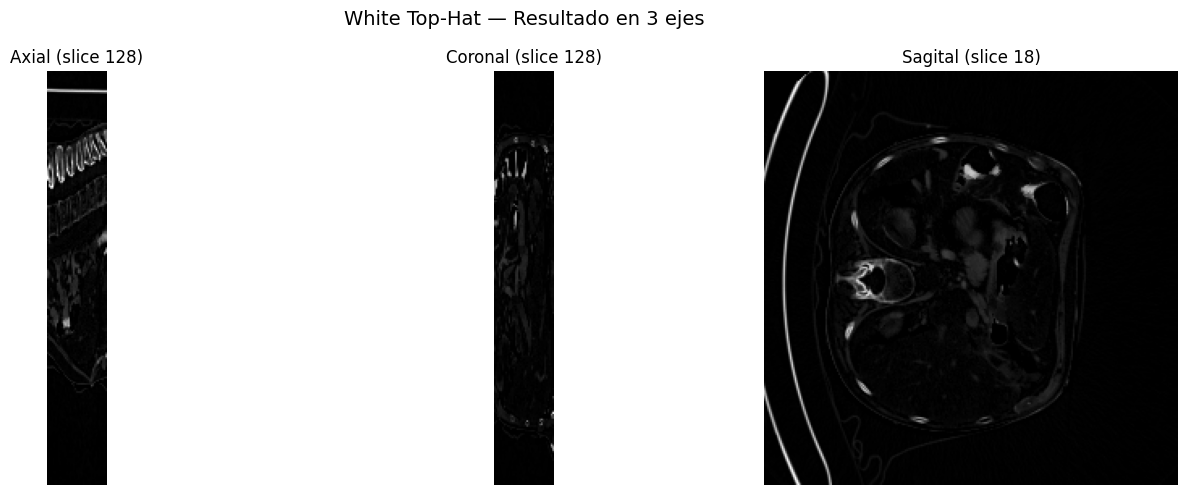

In [17]:
vol_pre='' #volumen pre-procesado 

# ball(3) genera una esfera de radio 3 vóxeles en 3D
se = ball(3)


# solo quedan los "picos" de intensidad más pequeños que la bola
vol_pre = white_tophat(volume1, se)



slice_axial   = volume1.shape[0] // 2   # slice central en Z
slice_coronal = volume1.shape[1] // 2   # slice central en Y
slice_sagital = volume1.shape[2] // 2   # slice central en X


# Elegimos slices libremente (los centrales son representativos)
slice_axial   = volume1.shape[0] // 2
slice_coronal = volume1.shape[1] // 2
slice_sagital = volume1.shape[2] // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('White Top-Hat — Resultado en 3 ejes', fontsize=14)

axes[0].imshow(vol_pre[slice_axial, :, :], cmap='gray')
axes[0].set_title(f'Axial (slice {slice_axial})')
axes[0].axis('off')

axes[1].imshow(vol_pre[:, slice_coronal, :], cmap='gray')
axes[1].set_title(f'Coronal (slice {slice_coronal})')
axes[1].axis('off')

axes[2].imshow(vol_pre[:, :, slice_sagital], cmap='gray')
axes[2].set_title(f'Sagital (slice {slice_sagital})')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [15]:
assert len(np.unique(vol_pre))>2, 'Deberia estar haciendo el pre-procesamiento en el volumen original, no en el predicho ni en el groundtruth'
assert np.isclose(np.sum(vol_pre!=0),2114154,0.001), 'No calculó bien el pre-procesamiento'

Podemos observar que el resultado anterior son las estructuras más brillantes que son de menor tamaño a nuestro elemento estructurante. Ahora que los tenemos extraidos, umbralice esta mascara para obtener solo los valores entre 70 y 1024, y elimine estas estructuras del volumen original para no tenerlas en cuenta.

> **Sugerencia:** Usted quiere eliminar los pixeles del volumen original que se encuentran en la nueva mascara creada, por lo que el objetivo será restar a cada pixel su **misma intensidad**. Piense como obtener la intensidad original de los pixeles de la mascara. 

Compare el resultado de la segmentación que usted propuso en un inicio con el volumen orignial y con este nuevo volumen. Haga un subplot donde se pueda ver el resultado en los 3 ejes.

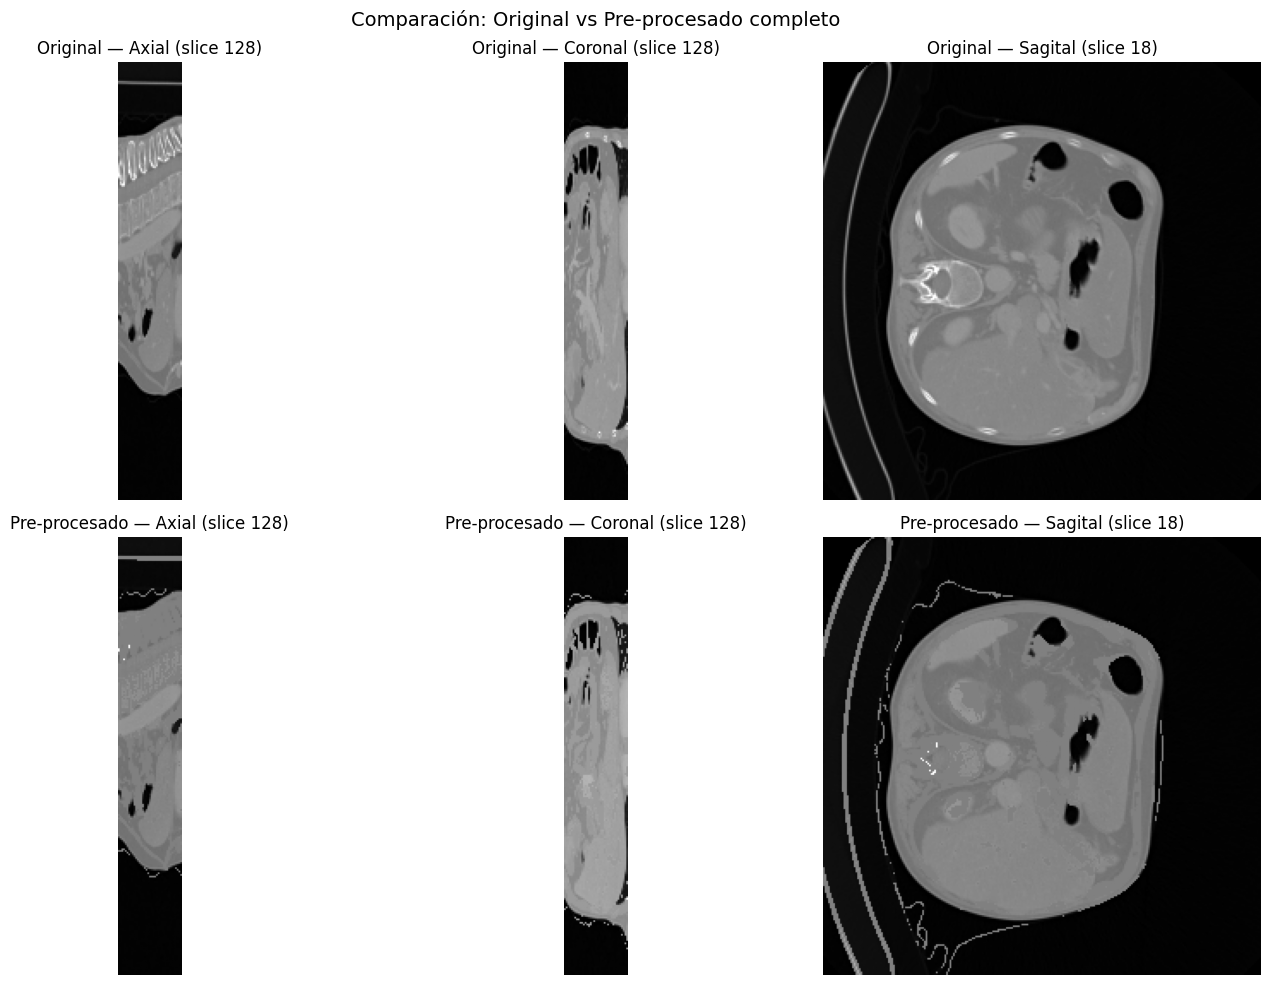

In [26]:
vol_pre_total='' #volumen pre-procesado completamente

# Creamos una máscara binaria con los píxeles del top-hat entre 70 y 1024
mascara_tophat = (vol_pre >= 70) & (vol_pre <= 1024)


# los píxeles seleccionados quedan en 0 y el resto no se toca
vol_pre_total = volume1 - (mascara_tophat * volume1)


# Usamos el slice sagital central que es el más informativo visualmente
slice_axial   = volume1.shape[0] // 2
slice_coronal = volume1.shape[1] // 2
slice_sagital = volume1.shape[2] // 2

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Comparación: Original vs Pre-procesado completo', fontsize=14)

# ── Fila 0: Volumen original ───────────────────────────────────────────────────
axes[0, 0].imshow(volume1[slice_axial, :, :], cmap='gray')
axes[0, 0].set_title(f'Original — Axial (slice {slice_axial})')
axes[0, 0].axis('off')

axes[0, 1].imshow(volume1[:, slice_coronal, :], cmap='gray')
axes[0, 1].set_title(f'Original — Coronal (slice {slice_coronal})')
axes[0, 1].axis('off')

axes[0, 2].imshow(volume1[:, :, slice_sagital], cmap='gray')
axes[0, 2].set_title(f'Original — Sagital (slice {slice_sagital})')
axes[0, 2].axis('off')

# ── Fila 1: Volumen pre-procesado (estructuras brillantes eliminadas) ──────────
axes[1, 0].imshow(vol_pre_total[slice_axial, :, :], cmap='gray')
axes[1, 0].set_title(f'Pre-procesado — Axial (slice {slice_axial})')
axes[1, 0].axis('off')

axes[1, 1].imshow(vol_pre_total[:, slice_coronal, :], cmap='gray')
axes[1, 1].set_title(f'Pre-procesado — Coronal (slice {slice_coronal})')
axes[1, 1].axis('off')

axes[1, 2].imshow(vol_pre_total[:, :, slice_sagital], cmap='gray')
axes[1, 2].set_title(f'Pre-procesado — Sagital (slice {slice_sagital})')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

In [27]:
assert len(np.unique(vol_pre_total))!=2, 'No hizo el pre-procesamiento completo en el volumen original sino en otro volumen'
assert np.min(vol_pre_total)>=-1024, 'Seguramente restó la mascara binaria directamente'
assert np.isclose(np.sum(vol_pre_total>0.8),278227,0.001), 'No realizó bien el pre-procesamiento para eliminar las estructuras en el volumen original'

AssertionError: No realizó bien el pre-procesamiento para eliminar las estructuras en el volumen original

Veamos como afecta este preprocesamiento a nuestro metodo de segmentación.

In [28]:
def Jaccard_3D(Im,Gt):
    '''
    :param Im: Volumen de prediccion.
    :param Gt: Segmentacion groundtruth.
    '''
    # Convertimos a booleano para asegurar operaciones lógicas correctas
    Im = Im.astype(bool)
    Gt = Gt.astype(bool)

    # Intersección: píxeles que están en AMBAS máscaras (verdaderos positivos)
    interseccion = np.sum(Im & Gt)

    # Unión: píxeles que están en AL MENOS UNA de las dos máscaras
    union = np.sum(Im | Gt)

    # Evitamos división por cero en caso de máscaras completamente vacías
    if union == 0:
        return 1.0

    # Jaccard = Intersección / Unión
    J = interseccion / union

    return J

In [29]:

J_sinpre=Jaccard_3D(aux_segment,segmen1)
segment_conpre=vol_max_component(vol_pre_total,200,30)
J_conpre=Jaccard_3D(segment_conpre,segmen1)

print(f'El jaccard sin preprocesamiento es: {J_sinpre}')
print(f'El jaccard con preprocesamiento es: {J_conpre}')

El jaccard sin preprocesamiento es: 0.36165285139138703
El jaccard con preprocesamiento es: 0.6041678693067021


In [30]:
fp2,fn2=errores(segment_conpre,segmen1)
print(f'Los falsos positivos del volumen no preprocesado es {np.sum(fp)}')
print(f'Los falsos positivos del volumen preprocesado es {np.sum(fp2)}')

print(f'Los falsos negativos del volumen no preprocesado es {np.sum(fn)}')
print(f'Los falsos negativos del volumen preprocesado es {np.sum(fn2)}')

Los falsos positivos del volumen no preprocesado es 265198
Los falsos positivos del volumen preprocesado es 55541
Los falsos negativos del volumen no preprocesado es 1333
Los falsos negativos del volumen preprocesado es 26743


Como podemos observar, el preprocesamiento aumentó los falsos negativos pero disminuyó los falsos positivos. El procesamiento que realizamos se ve beneficiado si se sobresegmenta.

El anterior procesamiento fue tan solo un ejemplo de lo que podemos lograr hacer con la morfología matematica en escala de grises. Planee una linea de base similar que le pueda ayudar a eliminar elementos que no le interesan o resaltar los objetos que si. Existen muchos algoritmos de morfología matematica y la combinación de ellos nos permiten hacer procesamientos verdaderamente interesantes. Luego, haga experimentos (minimo 4) con el tamaño, la forma y las dimensiones (2D o 3D) del elemento estructurante. El elemento estructurante que nosotros usamos era una Bola de radio 3, un elemento de 3 dimensiones que tiene skimage.morphology, ustedes pueden usar estos elementos estrcutrantes o diseñar uno como una matriz de numpy.

>**Nota:** Cree una linea de base verdaderamente util y que le ayude a mejorar sus metricas, no haga un procesamiento solo por hacerlo, de igual forma para los experimentos con el elemento estructurante. Observe sus volumenes de FP y de FN, seguramente les dará una idea.


>**Recuerde:** Estos procesamientos se hacen como pre-procesamiento, es decir, en el volumen original y no en la segmentación ya hecha.

In [52]:
# Con un radio mayor capturamos estructuras brillantes más grandes
se_exp1 = ball(5)
vol_tophat_exp1 = white_tophat(volume1, se_exp1)
mascara_exp1 = (vol_tophat_exp1 > 70) & (vol_tophat_exp1 < 1024)
vol_exp1 = np.where(mascara_exp1, 0, volume1)
seg_exp1 = vol_max_component(vol_exp1, 200, 30)
J_exp1 = Jaccard_3D(seg_exp1, segmen1)
print(f'Exp 1 — ball(5):                    Jaccard = {J_exp1:.4f}')

# Con radio menor solo eliminamos estructuras muy pequeñas y puntuales
se_exp2 = ball(1)
vol_tophat_exp2 = white_tophat(volume1, se_exp2)
mascara_exp2 = (vol_tophat_exp2 > 70) & (vol_tophat_exp2 < 1024)
vol_exp2 = np.where(mascara_exp2, 0, volume1)
seg_exp2 = vol_max_component(vol_exp2, 200, 30)
J_exp2 = Jaccard_3D(seg_exp2, segmen1)
print(f'Exp 2 — ball(1):                    Jaccard = {J_exp2:.4f}')

# Combinación top-hat ball(3) aplicado sobre apertura del volumen original
# La apertura suaviza el ruido antes de aplicar el top-hat
vol_tophat_exp3 = white_tophat(volume1, ball(3))
mascara_exp3 = (vol_tophat_exp3 > 70) & (vol_tophat_exp3 < 1024)
vol_opened_exp3 = opening(volume1, ball(3))
vol_exp3 = np.where(mascara_exp3, 0, vol_opened_exp3)
seg_exp3 = vol_max_component(vol_exp3, 200, 30)
J_exp3 = Jaccard_3D(seg_exp3, segmen1)
print(f'Exp 3 — tophat(3) + opening(3):     Jaccard = {J_exp3:.4f}')

# Combinación opening + closing: primero eliminamos ruido brillante con opening
# luego rellenamos huecos oscuros con closing, ambos con ball(3)
vol_opened_exp4  = opening(volume1, ball(3))   # elimina picos de intensidad
vol_exp4         = closing(vol_opened_exp4, ball(3))  # rellena valles oscuros
seg_exp4 = vol_max_component(vol_exp4, 200, 30)
J_exp4 = Jaccard_3D(seg_exp4, segmen1)
print(f'Exp 4 — opening(3) + closing(3):    Jaccard = {J_exp4:.4f}')

print(f'\n── Resumen ──────────────────────────────────')
print(f'Sin preprocesamiento:               Jaccard = {J_sinpre:.4f}')
print(f'Baseline (ball 3):                  Jaccard = {J_conpre:.4f}')
print(f'Exp 1 — ball(5):                    Jaccard = {J_exp1:.4f}')
print(f'Exp 2 — ball(1):                    Jaccard = {J_exp2:.4f}')
print(f'Exp 3 — tophat(3) + opening(3):     Jaccard = {J_exp3:.4f}')
print(f'Exp 4 — opening(3) + closing(3):    Jaccard = {J_exp4:.4f}')

Exp 1 — ball(5):                    Jaccard = 0.6948
Exp 2 — ball(1):                    Jaccard = 0.3970
Exp 3 — tophat(3) + opening(3):     Jaccard = 0.2951
Exp 4 — opening(3) + closing(3):    Jaccard = 0.2951

── Resumen ──────────────────────────────────
Sin preprocesamiento:               Jaccard = 0.3617
Baseline (ball 3):                  Jaccard = 0.6042
Exp 1 — ball(5):                    Jaccard = 0.6948
Exp 2 — ball(1):                    Jaccard = 0.3970
Exp 3 — tophat(3) + opening(3):     Jaccard = 0.2951
Exp 4 — opening(3) + closing(3):    Jaccard = 0.2951


Por ultimo, cree una función que resuma por completo su preprocesamiento. Recuerde que la idea es que se mejore nuestra segmentación final, esta será parte de su nota. Cree la función que entre por parametro un volumen unicamente. El resto de parametros como elementos estructurantes, tamaños, umbrales, etc. deben ir por defecto.

In [59]:
def preprocesamiento_total(vol):
    """Pipeline completo de pre-procesamiento morfológico en escala de grises.

    Aplica un white top-hat para identificar estructuras brillantes pequeñas
    (huesos, vasos) y las elimina del volumen original para facilitar la
    segmentación del hígado.

    Args:
        vol (ndarray): Volumen MRI original en escala de grises

    Returns:
        volume_preprocessed (ndarray): Volumen pre-procesado listo para segmentar
    """

    # Paso 1: White top-hat para extraer estructuras brillantes pequeñas
    vol_tophat = white_tophat(vol, ball(3))

    # Paso 2: Máscara de estructuras a eliminar
    mascara = (vol_tophat > 70) & (vol_tophat < 1024)

    # Paso 3: Apertura para suavizar el volumen antes de eliminar estructuras
    vol_opened = opening(vol, ball(3))

    # Paso 4: Eliminar estructuras brillantes del volumen suavizado
    volume_preprocessed = np.where(mascara, 0, vol_opened)
    
    return volume_preprocessed
# ─── EVALUACIÓN EN CONJUNTO DE VALIDACIÓN ─────────────────────────────────────

mean_jaccard = 0.0
vol_val_paths = glob(os.path.join('DB', 'valid', 'volume_*.nii.gz'))
seg_val_paths = glob(os.path.join('DB', 'valid', 'segmentation_*.nii.gz'))

for i, (vol_val_path, seg_val_path) in enumerate(zip(sorted(vol_val_paths), sorted(seg_val_paths)), start=1):
    vol_val = nib.load(vol_val_path).get_fdata()
    seg_val = nib.load(seg_val_path).get_fdata() > 0

    vol_pre_total2 = preprocesamiento_total(vol_val)
    vol_segmentado = vol_max_component(vol_pre_total2, 220, 30)
    jaccard_valid  = Jaccard_3D(vol_segmentado, seg_val)

    mean_jaccard += (jaccard_valid - mean_jaccard) / i


In [60]:
mean_jaccard = 0.0
vol_val_paths = glob(os.path.join('DB','valid','volume_*.nii.gz'))
seg_val_paths = glob(os.path.join('DB','valid','segmentation_*.nii.gz'))
pbar = tqdm(total=len(vol_val_paths))
for i, (vol_val_path, seg_val_path) in enumerate(zip(vol_val_paths, seg_val_paths), start = 1):
    vol_val = nib.load(vol_val_path).get_fdata()
    seg_val = nib.load(seg_val_path).get_fdata()>0
    vol_pre_total2 = preprocesamiento_total(vol_val)
    vol_segmentado = vol_max_component(vol_pre_total2, 220, 30)
    jaccard_valid = Jaccard_3D(vol_segmentado,seg_val)
    mean_jaccard += (jaccard_valid - mean_jaccard) / i
    pbar.update(1)
pbar.close()
print(f'El jaccard medio de validacion es: {mean_jaccard}')

  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:45<00:00,  9.13s/it]

El jaccard medio de validacion es: 0.5247456886714558


In [61]:
assert mean_jaccard>0.37, 'El jaccard de su preprocesamiento total debe ser mayor al preprocesamiento propuesto'

### Parte 2: Operación morfológica como post-procesamiento
Otra metodología que podemos llevar a cabo para mejorar nuestras mascaras de segmentación es la morfología binaria en las mascaras de segmentación. A diferencia de el pre-procesamiento en escala de grises, que busca resaltar o eliminar elementos en la imagen original para facilitar el proceso de prediccion del modelo, el post-procesamiento busca eliminar imperfecciones de las mascaras predichas por el modelo. En ese sentido, el post-procesamiento lo diseñaremos en base a las imperfecciones de la mascara y conociendo la forma de nuestro objeto de interes, olvidandonos por completo de nuestra imagen original.

**Importante:** Para disminuir los tiempos de carga utilice la funciones especialmente diseñadas para imágenes o volúmenes binarios.

#### Parte 2.1: Visualización de la mascara binaria
Para poder diseñar una linea de base con la que podamos mejorar nuestra predicción final primero debemos visualizar los errores de nuestra mascara. Recuerden que, al igual que los filtros, un procesamiento puede ayudar a nuestro resultado final o empeorarlo, por lo que hacer un procesamiento a ciegas sin conocer las limitaciones de nuestro modelo es una mala idea. Recorra nuevamente todo su volumen de predicción con el mejor preprocesamiento encontrado en el punto anterior y obtenga un volumen que tenga los pixeles falsos positivos y los pixeles falsos negativos como en el primer punto. Visualice de la misma forma los slice con más FP y FN junto con la mascara original y su mascara predicha en un subplot.

In [ ]:
# importar funciones importantes
from skimage.morphology import binary_closing, binary_opening, binary_erosion, binary_dilation

In [ ]:
vol_preprocesado='' #volumen final pre-procesado
vol_segmentado='' #volumen segmentado con el pre-procesamiento
FP_sinpost='' #volumen con pixeles unicamente Falsos Positivos
FN_sinpost='' #volumen con pixeles unicamente Falsos Negativos

# YOUR CODE HERE
raise NotImplementedError()

#### Parte 2.2: Operaciones morfologicas como post-procesamiento
Ahora, ya usted fué capaz de observar cuales fueron sus principales fallos en su mascara de segmentación con un volumen pre-procesado. Dependiendo de su caso, use una apertura o una clausura con una bola de radio 1 para mejorar su resultado.

In [ ]:
vol_post='' #volumen post-procesado
# YOUR CODE HERE
raise NotImplementedError()

In [ ]:
assert len(np.unique(vol_post))==2, 'No esta post-procesando en el volumen binario predicho'
assert Jaccard_3D(vol_post,segmen1)>Jaccard_3D(vol_segmentado,segmen1), 'Su post-procesamiento no mejora su predicción'

Realice tambien 2 experimentos adicionales con las operaciones basicas, *erosion* y *dilatacion* para mejorar su mascara de segmentación. Los procesos que elija dependerán mucho de si usted sobresegmentó o subsegmentó. Experimente con tamaños y dimensiones del elemento estructurante o incluso, con aperturas y clausuras iterativas.

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

Un procedimiento muy interesante que podemos llevar a cado es la recontrucción geodesica para obtener unicamente el hígado. El procedimiento es el siguiente:

>1. Erosionamos nuestro volumen con un elemento estructurante grande. Use una *ball* de radio 5. Esto nos dará como resultado los pixeles de los elementos más grandes del volumen.
>2. Usaremos un elemento estructurante pequeño para realizar una dilatación del resultado anterior. Use una *ball* de radio 1. 
>3. A el resultado del punto **2** le realizaremos una intersección con la mascara original, el volumen previo a la erosión con el elmento grande.
>4. Repita los puntos del 2 al 3 de forma iterativa hasta que el resultado no cambie.

Use la siguiente celda para realizar la reconstrucción geodesica de su volumen luego de la apertura del punto anterior y calcule el Jaccard3D para cuantificar la mejora. Cree una función que entre como parametro la segmentación como mascara, el elemento estructurante E1 con el que se hará la erosión, el elemento estructurante E2 con el que se hará la dilatación y un numero maxximo de iteraciones para no tener loops infinitos. Debe retornar el resultado de la dilatación geodesica y el numero de iteraciones.

In [ ]:
def geodesic_dilatation(mask, E1,E2,max_iterations):
    # YOUR CODE HERE
    raise NotImplementedError()
    return result,iterations

In [ ]:
vol_post_2='' #volumen de postprocesamiento total previo a la dilatación geodesica
E1='' # elemento estructurante para la erosión
E2='' # elemento estructurante para la dilatación
max_iterations='' #iteraciones maximas
# YOUR CODE HERE
raise NotImplementedError()

In [ ]:
assert np.sum(E1)==515, 'La erosión se está realizando con un elemento erroneo'
assert np.sum(E2)==7, 'La dilatacíon se está realizando con un elemento erroneo'

In [ ]:
reconstruccion,iterations=geodesic_dilatation(vol_post,E1,E2,max_iterations) # Esta función puede demorar en correr alrededor de 5 minutos

In [ ]:
Jaccard_3D(reconstruccion,segmen1)

In [ ]:
assert iterations<max_iterations, 'Sus maximas iteraciones deben ser mayores a las iteraciones completas'
assert np.sum(reconstruccion), 'Su volumen de reconstrucción está vacio'
assert np.sum(reconstruccion)!=np.sum(vol_post), 'No realizó ningun procesamiento'
assert np.isclose(np.sum(dilation(reconstruccion.astype(int), E2)*vol_post-reconstruccion.astype(int)),0) or iterations==max_iterations, f'La dilatación de la reconstrucción intesección con la mascara no es igual a la reconstrucción, no se realizó bien la geodesic_dilatation'

Nuestras metricas seguramente hayan mejorado con este post-procesamiento, ya que eliminamos todos los elementos menores a nuestro elemento estructurante sin dañar tanto nuesto organo de interes. Sin embargo, nuestra mascara aun está lejos de ser perfecta, diseñe una linea de base con la que podrá mejorar su mascara de segmentación usando los algoritmos de skimage.morphology. Luego, realice algunos experimentos (minimo 4) con los que podrá mejorar su resultado final, modifique el tamaño del elemento estructurante, la forma y las dimensiones (2D y 3D). Pruebe tambien otras operaciones morfologicas como el relleno de huecos o el miss or hit si es necesario. Recuerde que nuestro baseline de tomar el elemento conexo mayor es un post-procesamiento, modifiquelo como crea oportuno tambien. Parte de su nota será mejorar la segmentación por medio del post-procesamiento

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

Por ultimo, realice una función que genere el postprocesamiento de un volumen binario que entre por parametro que realice todo el procedimiento que usted planteó.

In [ ]:
def postprocesamiento_total(vol):
    # YOUR CODE HERE
    raise NotImplementedError()
    return vol_post

In [ ]:
mean_jaccard = 0.0
vol_val_paths = glob(os.path.join('DB','valid','volume_*.nii.gz'))
seg_val_paths = glob(os.path.join('DB','valid','segmentation_*.nii.gz'))
pbar = tqdm(total=len(vol_val_paths))
for i, (vol_val_path, seg_val_path) in enumerate(zip(vol_val_paths, seg_val_paths), start = 1):
    vol_val = nib.load(vol_val_path).get_fdata()
    seg_val = nib.load(seg_val_path).get_fdata()>0
    vol_pre_total2 = preprocesamiento_total(vol_val)
    vol_segmentado = vol_max_component(vol_pre_total2, 200, 30)
    vol_post = postprocesamiento_total(vol_segmentado)
    jaccard_valid = Jaccard_3D(vol_post,seg_val)
    mean_jaccard += (jaccard_valid - mean_jaccard) / i
    pbar.update(1)
pbar.close()
print(f'El jaccard medio de validacion es: {mean_jaccard}')

In [ ]:
assert mean_jaccard>0.46, 'El Jaccard del preprocesamiento propuesot por usted debe ser mayor al propuesto por nosotros'

## Entregables
Los entregables para esta entrega son un Jupyter notebook (.ipynb), un informe (.pdf) y un archivo de texto (.txt).

El Jupyter notebook debe estar completamente resuelto. Recuerde que la nota depende del funcionamiento de su código. El archivo de texto corresponde a las secciones de código de su Jupyter notebook, para más información sobre cómo convertir las secciones de código del Jupyter notebook a archivo de texto ver el video en el siguiente [enlace](https://uniandes-edu-co.zoom.us/rec/share/QOxUUIw7Uz9DsnKPyftOXZgM4bx5d7KHMYK-dqvGnkyJ2GfqvT7NU3lhQc0NtNSU.jveWB2H34S4uLIoB).

En este miniproyecto debe hacer un informe con Introducción, Resultados y análisis, y Conclusiones respondiendo las preguntas en las secciones donde usted crea pertinente responderlas. Toda la información sobre secciones, preguntas y elementos adicionales está en la siguiente sección de informe. La extensión máxima del informe es de 4 páginas. El informe debe utilizar el formato que puede encontrar siguiente [enlace](https://github.com/cvpr-org/author-kit). Si tiene dudas de cómo utilizar el formato puede preguntar al Asistente Graduado.

## Informe
Ya hemos realizado todo un procedimiento de pre-procesamiento y post-procesamiento para mejorar los resultados finales de nuestro modelo. Recuerde que queremos observar la sensibilidad de nuestro modelo a los diferentes parametros que hemos probado para así obtener el mejor proceso posible y habrán ocasiones en las que combinaciones de parametros funcionarán mejor que los parametros individuales, tengalo en cuenta. 

No olvide contestar las siguientes preguntas en su informe:

### Operación morfológica como pre-procesamiento
* Teniendo en cuenta nuestro metodo de segmentación usando el elemento conexo más grande ¿De que forma es útil el preprocesamiento? ¿Como explica el aumento en el indice de Jaccard?
* ¿Por qué nuestro procesamiento (el realizado en la sección 1.2, antes de la función de preprocesamiento total) aumenta los falsos negativos pero disminuye los falsos positivos?
* ¿Cree que el pre-procesamiento con escala de grises es necesario? ¿Puede obtener resultados similares usando simplemente el post-procesamiento? 
* Describa sus experimentos y explique su razon de ser, analice sus resultados. Incluya tambien una explicación de su pre-procesamiento total.

### Operación morfológica como post-procesamiento
* ¿Que errores en la mascara binaria permanecieron aun con el uso del preprocesamiento?
* ¿El procedimiento propuesto de la reconstrucción geodesica funcionará para segmentar algun otro organo que no sea el higado? ¿Que limitaciones tiene esta metodología?
* ¿Sus resultados son mayores con pre-procesamiento, con post-procesamiento o con ambos? ¿Por que?
* Describa sus experimentos y explique su razon de ser, analice sus resultados. Incluya tambien una explicación de su post-procesamiento total.

In [ ]:
from utils import *
converter("Entrega 2")